In [2]:
import os
import numpy as np
from netCDF4 import Dataset
import xlwt
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
df = pd.read_csv('./观测预测.csv')
df_mod = pd.read_csv('../求acc模式/观测模式.csv')

### prmse

In [9]:
df = pd.read_csv('./观测预测.csv')
df_mod = pd.read_csv('../求acc模式/观测模式.csv')
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())
# Group by 'Stn_No'
sd_grouped = df.groupby('Stn_No')
mod_grouped = df_mod.groupby('Stn_No')

sd_rmse_values = []
for name, group in sd_grouped:
    sd_rmse = rmse(group['prep'], group['obs_percent'])
    sd_rmse_values.append({'Stn_No': name, 'sd_rmse': sd_rmse})
rmse_sd = pd.DataFrame(sd_rmse_values)

mod_rmse_values = []
for name, group in mod_grouped:
    mod_rmse = rmse(group['mod_percent'], group['obs_percent'])
    mod_rmse_values.append({'Stn_No': name, 'mod_rmse': mod_rmse})
rmse_mod = pd.DataFrame(mod_rmse_values)

merged_rmse = pd.merge(rmse_mod, rmse_sd, on='Stn_No', how='outer')
merged_rmse['prmse'] = ((merged_rmse['mod_rmse']-merged_rmse['sd_rmse'])/merged_rmse['mod_rmse'])*100
print(merged_rmse)


      Stn_No  mod_rmse   sd_rmse      prmse
0      50136  0.273662  0.226774  17.133492
1      50137  0.375449       NaN        NaN
2      50246  0.279453  0.251566   9.978988
3      50247  0.306346  0.266074  13.145815
4      50349  0.245572  0.231396   5.772723
...      ...       ...       ...        ...
2453   59948  0.280973  0.260624   7.242536
2454   59951  0.311178  0.241777  22.302532
2455   59954  0.283050  0.282734   0.111391
2456   59981  0.360149  0.317178  11.931459
2457   59985  0.399813  0.368533   7.823701

[2458 rows x 4 columns]


<xarray.DataArray (lat: 60, lon: 70)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) int32 60 59 58 57 56 55 54 53 52 51 ... 10 9 8 7 6 5 4 3 2 1
  * lon      (lon) int32 70 71 72 73 74 75 76 77 ... 133 134 135 136 137 138 139


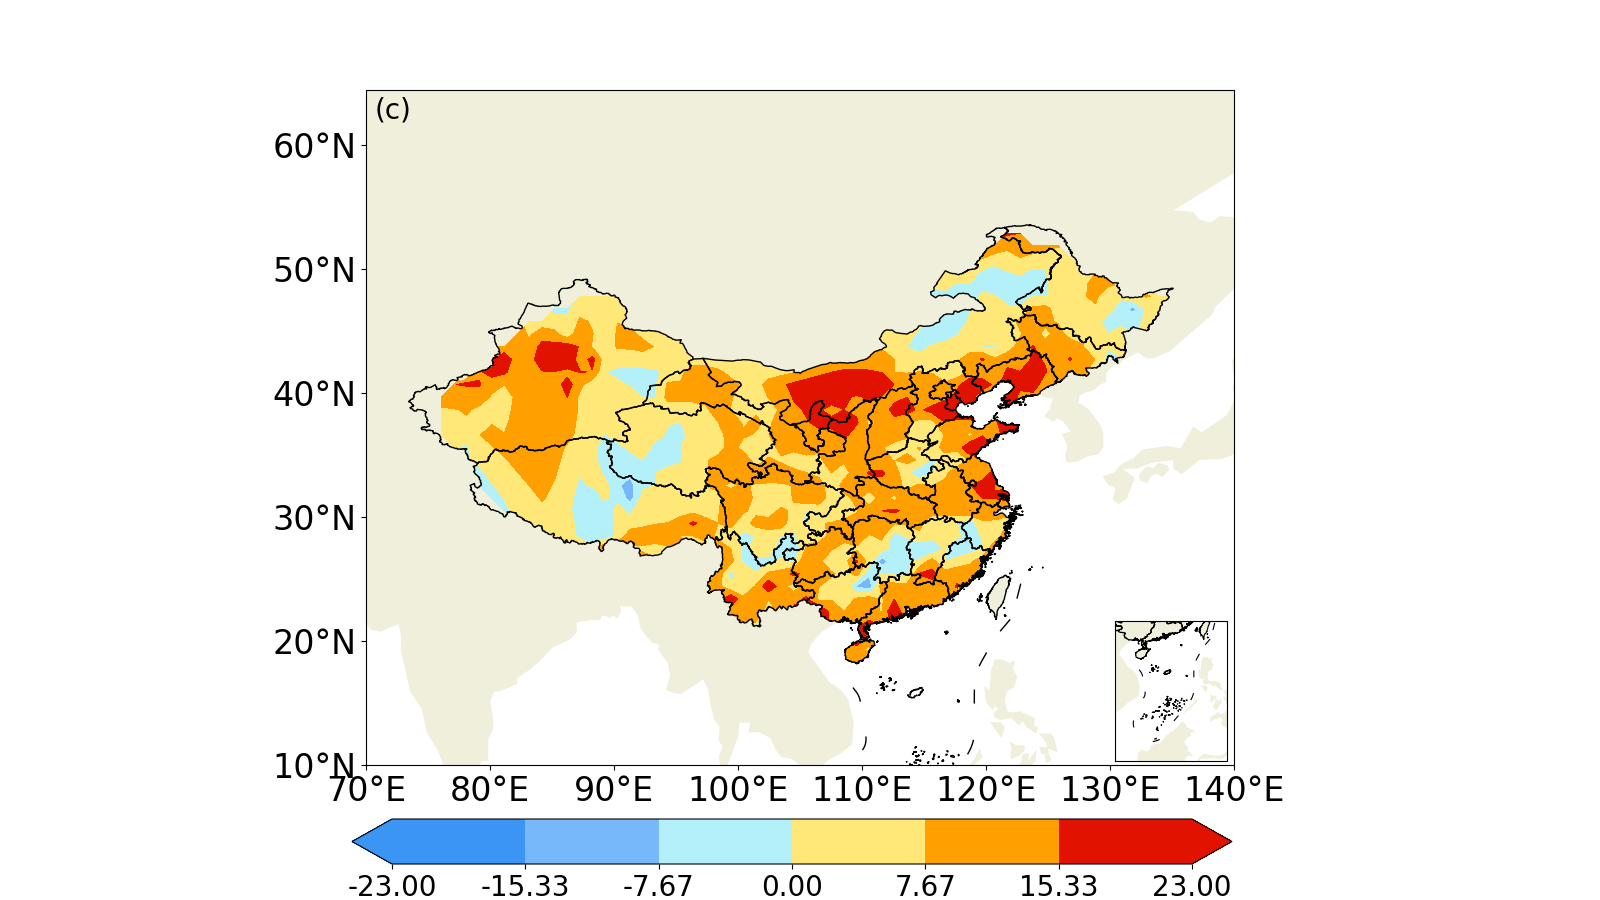

In [11]:
#模态画图——降水——格点数据——地图
import os
import numpy as np
from netCDF4 import Dataset
import xlwt
import pandas as pd
import xarray as xr
from metpy.interpolate import inverse_distance_to_grid
from functools import reduce
import sys
import maskout
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib as mpl
import cartopy.feature as cfeature
from netCDF4 import Dataset
from cartopy.util import add_cyclic_point
import matplotlib.colors as colors
import matplotlib.ticker as ticker
from scipy.interpolate import griddata

np.set_printoptions(suppress=True)

# draw_what = prmse
df = pd.read_csv('E:\\D1\\f01\\xg6\\result.csv')
df = df.drop(['time', 'Precip'], axis=1)
df = df.drop_duplicates('Stn_No')
df_mode = merged_rmse

# 按照'Stn_No'列来合并数据表
df_final = pd.merge(df, df_mode, how='left', on='Stn_No')
df_final = df_final.dropna()
df_final = df_final.drop(['mod_rmse','sd_rmse'], axis=1)

# 显示结果
min_long = df_final['Long'].min()/100
max_long = df_final['Long'].max()/100
min_lat = df_final['Lat'].min()/100
max_lat = df_final['Lat'].max()/100
target_lons = np.arange(70, 140, 1)
target_lats = np.arange(60, 0, -1)

# 创建目标经纬度的网格
target_grid_lon, target_grid_lat = np.meshgrid(target_lons, target_lats)

# 插值
grid_z = griddata((df_final['Long']/100, df_final['Lat']/100),df_final['prmse'], (target_grid_lon, target_grid_lat),method='linear')
# print(grid_z)
# 创建插值后的xarray.DataArray
draw_what = xr.DataArray(grid_z, coords=[('lat', target_lats), ('lon', target_lons)])

# 显示结果
print(draw_what)

class MidpointNormalize(colors.Normalize): 
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))



lon = np.linspace(70, 140, np.shape(draw_what)[1])
lat = np.linspace(60, 0, np.shape(draw_what)[0])
# # 画下面的彩色条子
min_of_draw_what = -23
max_of_draw_what = 23
# min_of_draw_what = round(float(np.min(draw_what))*0.8, 2)
# max_of_draw_what = round(float(np.max(draw_what))*0.8, 2)
lim = np.concatenate((np.linspace(min_of_draw_what,0,4),np.delete(np.linspace(0,max_of_draw_what,4), 0)),axis=0)
# lim = [0,7,14,21]


# 地图界限
with open('../../CN-border-La.gmt') as src:
    context = src.read()
    blocks = [cnt for cnt in context.split('>') if len(cnt) > 0]
    borders = [np.fromstring(block, dtype=float, sep=' ') for block in blocks]

fig = plt.figure(figsize=(16,9),facecolor='white')
myproj = ccrs.PlateCarree(central_longitude=0.0)#ccrs跟绘地图有关#调整图像中心位置
ax = fig.add_axes([0.10, 0.15, 0.8, 0.75],projection=myproj)#add_axes通过相对位置增加子图 
ax.add_feature(cfeature.LAND.with_scale('110m'))
for line in borders:
    ax.plot(line[0::2], line[1::2], '-', lw=1, color='k',
            transform=ccrs.Geodetic())
    
# Plot gridlines绘制网格线
#ax.gridlines(linestyle='--')

# Set figure extent设置图范围
ax.set_extent([70, 140, 10, 60])#摆正图像
# ax.set_xticks([70,80,90,100,110,120,130,140],crs=ccrs.PlateCarree())
# ax.set_yticks([10,20,30,40,50],crs=ccrs.PlateCarree())
ax.set_xticks(range(70,141,10),crs=ccrs.PlateCarree())
ax.set_yticks(range(10,61,10),crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(zero_direction_label=False)
lat_formatter = LatitudeFormatter()#定义一种坐标刻度样式为维度刻度	
ax.xaxis.set_major_formatter(lon_formatter)#改变X轴主刻度为经度样式
ax.yaxis.set_major_formatter(lat_formatter)
plt.tick_params(axis='both',labelsize=24)#刻度的字号
cmap1 = mpl.colors.ListedColormap(['#E11300', '#FF3100', '#FF9F00', '#FFBF3B', '#FFE877','#B3F0FA', '#95D2FA', '#77B8FA', '#4FA4F5', '#3B95F5'])#冷大
cmap1 = mpl.colors.ListedColormap(['#3B95F5', '#4FA4F5', '#77B8FA', '#95D2FA', '#B3F0FA','#FFE877', '#FFBF3B', '#FF9F00', '#FF3100', '#E11300'])#暖大
# cmap1.set_over('darkred')
# cmap1.set_under('navy')    #22就是最后一年，2016年
cf=plt.contourf(lon,lat,draw_what,levels=lim,cmap =cmap1,extend='both',zorder=0,transform=ccrs.PlateCarree(),norm=MidpointNormalize(midpoint=0))#画出等高线


colors =mpl.colors.ListedColormap(['black'])
# plt.title('precipitation anomaly', fontsize=14)
#plt.legend((),('A1',),loc='upper left',fontsize=20,ncol=2)
# plt.title('D2',fontsize=60,loc='left',y=0.85,x=0.02)#标题和标题大小
formatter = ticker.FormatStrFormatter('%.2f')
cbar=plt.colorbar(cf,cax=fig.add_axes([0.22, 0.04, 0.55, 0.05]),format=formatter, orientation='horizontal',cmap=cmap1)
cbar.ax.tick_params(labelsize=20)#条子的字号

clip=maskout.shp2clip(cf,ax, r'../../data/province/china0.shp')
sub_ax = fig.add_axes([0.662, 0.155, 0.14, 0.155],projection=myproj)#小南海的位置
sub_ax.add_feature(cfeature.LAND.with_scale('110m'))
for line in borders:
    sub_ax.plot(line[0::2], line[1::2], '-', lw=0.8, color='k',
                transform=ccrs.Geodetic())
# Set figure extent设置图范围
sub_ax.set_extent([105, 125, 0, 25]) 
plt.subplots_adjust()
plt.text(.01, .99, '(c)', ha='left', va='top', transform=ax.transAxes, fontsize=20)
plt.show()
plt.savefig("../pictures/tcc/c.svg",format="svg")

### ps

In [13]:
df = pd.read_csv('./观测预测.csv')
df_mod = pd.read_csv('../求acc模式/观测模式.csv')
a,b,c=2,2,4
ps_mod_list = []
for j in range(1994,2017):#mod
    # fcst = df[df['year'] == j].reset_index(drop=True)['sd_percent']
    fcst = df_mod[df_mod['year'] == j].reset_index(drop=True)['mod_percent']
    obs=df[df['year'] == j].reset_index(drop=True)['obs_percent']
    n=len(obs)
    n0,n1,n2,m=0,0,0,0
    for i in range(n):
        #print(i)
        if np.abs(obs[i])>=100:
            m=m+1
        if obs[i]*fcst[i]>=0:
            n0=n0+1
            if np.abs(obs[i])>=100:
                if np.abs(fcst[i])>=50:
                    m=m-1
            elif np.abs(obs[i])>=50:
                if np.abs(fcst[i])>=50:
                    n2=n2+1
            elif np.abs(obs[i])>=20:
                if np.abs(fcst[i])>=20 and np.abs(fcst[i])<50:
                    n1=n1+1
    ps=100*(a*n0+b*n1+c*n2)/(n-n0+a*n0+b*n1+c*n2+m)
    ps_mod_list.append({'year':j,'mod_ps':ps})
ps_mod = pd.DataFrame(ps_mod_list)

ps_sd_list = []
for j in range(1994,2017):#sd
    fcst = df[df['year'] == j].reset_index(drop=True)['prep']
    obs=df[df['year'] == j].reset_index(drop=True)['obs_percent']
    n=len(obs)
    n0,n1,n2,m=0,0,0,0
    for i in range(n):
        #print(i)
        if np.abs(obs[i])>=100:
            m=m+1
        if obs[i]*fcst[i]>=0:
            n0=n0+1
            if np.abs(obs[i])>=100:
                if np.abs(fcst[i])>=50:
                    m=m-1
            elif np.abs(obs[i])>=50:
                if np.abs(fcst[i])>=50:
                    n2=n2+1
            elif np.abs(obs[i])>=20:
                if np.abs(fcst[i])>=20 and np.abs(fcst[i])<50:
                    n1=n1+1
    ps=100*(a*n0+b*n1+c*n2)/(n-n0+a*n0+b*n1+c*n2+m)
    ps_sd_list.append({'year':j,'sd_ps':ps})
ps_sd = pd.DataFrame(ps_sd_list)
merged_ps = pd.merge(ps_mod,ps_sd, on='year', how='outer')

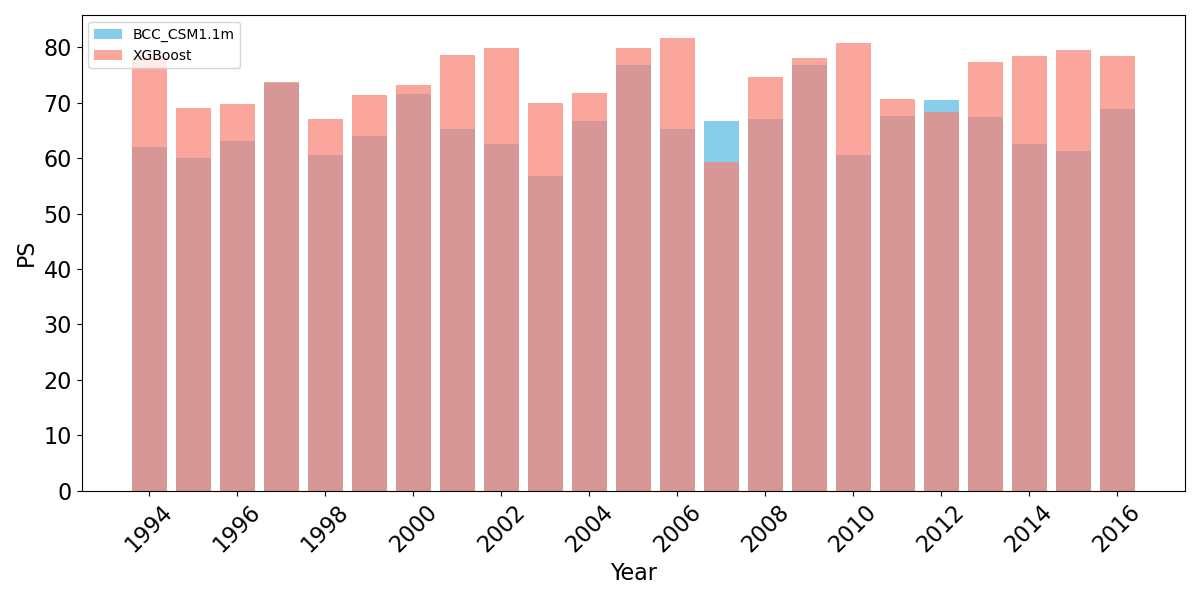

In [14]:
# Load the data from the CSV file
data = merged_ps

# Create a bar chart with narrower bar width
plt.figure(figsize=(12, 6))
plt.bar(data['year'], data['mod_ps'], color='skyblue', label='BCC_CSM1.1m')
plt.bar(data['year'], data['sd_ps'], color='salmon', label='XGBoost', alpha=0.7)
plt.xlabel('Year',fontsize=16)
plt.ylabel('PS',fontsize=16)
# plt.title('mod_ps vs sd_ps Over the Years')
plt.legend(loc='upper left')
plt.xticks(data['year'][::2], rotation=45 ,fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()
plt.savefig("../pictures/tcc/ps.svg",format="svg")

### TCC_SD

In [7]:
df = pd.read_csv('./观测预测.csv')
df_mod = pd.read_csv('../求acc模式/观测模式.csv')
mean_values = df.groupby('Stn_No')[['Precip', 'prep']].mean()
# subtract mean from percent and prep values
df['X'] = df['Precip'] - df['Stn_No'].map(mean_values['Precip'])
df['Y'] = df['prep'] - df['Stn_No'].map(mean_values['prep'])
df['XY'] = df['X'] * df['Y']
sum_XY = df.groupby('Stn_No')['XY'].sum()
df['X_square'] = df['X'] ** 2
df['Y_square'] = df['Y'] ** 2
sum_X_square = df.groupby('Stn_No')['X_square'].sum()
sum_Y_square = df.groupby('Stn_No')['Y_square'].sum()
sqrt_sum = (sum_X_square * sum_Y_square) ** 0.5
tcc_sd = sum_XY / sqrt_sum
tcc_sd = pd.DataFrame({'Stn_No': tcc_sd.index, 'tcc': tcc_sd.values})
tcc_sd.set_index('Stn_No', inplace=True)
print(tcc_sd)

             tcc
Stn_No          
50136   0.560566
50137        NaN
50246   0.476502
50247   0.495475
50349   0.344848
...          ...
59948   0.089708
59951   0.480291
59954   0.047667
59981   0.485257
59985   0.469101

[2458 rows x 1 columns]


In [3]:
df = pd.read_csv('./观测预测.csv')
df_mod = pd.read_csv('../求acc模式/观测模式.csv')
mean_values_mod = df_mod.groupby('Stn_No')[['Precip', 'mod_percent']].mean()
# subtract mean from percent and prep values
df_mod['X'] = df_mod['Precip'] - df_mod['Stn_No'].map(mean_values_mod['Precip'])
df_mod['Y'] = df_mod['mod_percent'] - df_mod['Stn_No'].map(mean_values_mod['mod_percent'])
df_mod['XY'] = df_mod['X'] * df_mod['Y']
sum_XY_mod = df_mod.groupby('Stn_No')['XY'].sum()
df_mod['X_square'] = df_mod['X'] ** 2
df_mod['Y_square'] = df_mod['Y'] ** 2
sum_X_square_mod = df_mod.groupby('Stn_No')['X_square'].sum()
sum_Y_square_mod = df_mod.groupby('Stn_No')['Y_square'].sum()
sqrt_sum_mod = (sum_X_square_mod * sum_Y_square_mod) ** 0.5
tcc_mod = sum_XY_mod / sqrt_sum_mod
tcc_mod = pd.DataFrame({'Stn_No': tcc_mod.index, 'tcc': tcc_mod.values})
tcc_mod.set_index('Stn_No', inplace=True)
print(tcc_mod)

             tcc
Stn_No          
50136  -0.085618
50137   0.046390
50246   0.035282
50247  -0.130646
50349   0.115222
...          ...
59948  -0.019030
59951  -0.288452
59954   0.108135
59981   0.084674
59985   0.244034

[2458 rows x 1 columns]


<xarray.DataArray (lat: 60, lon: 70)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) int32 60 59 58 57 56 55 54 53 52 51 ... 10 9 8 7 6 5 4 3 2 1
  * lon      (lon) int32 70 71 72 73 74 75 76 77 ... 133 134 135 136 137 138 139


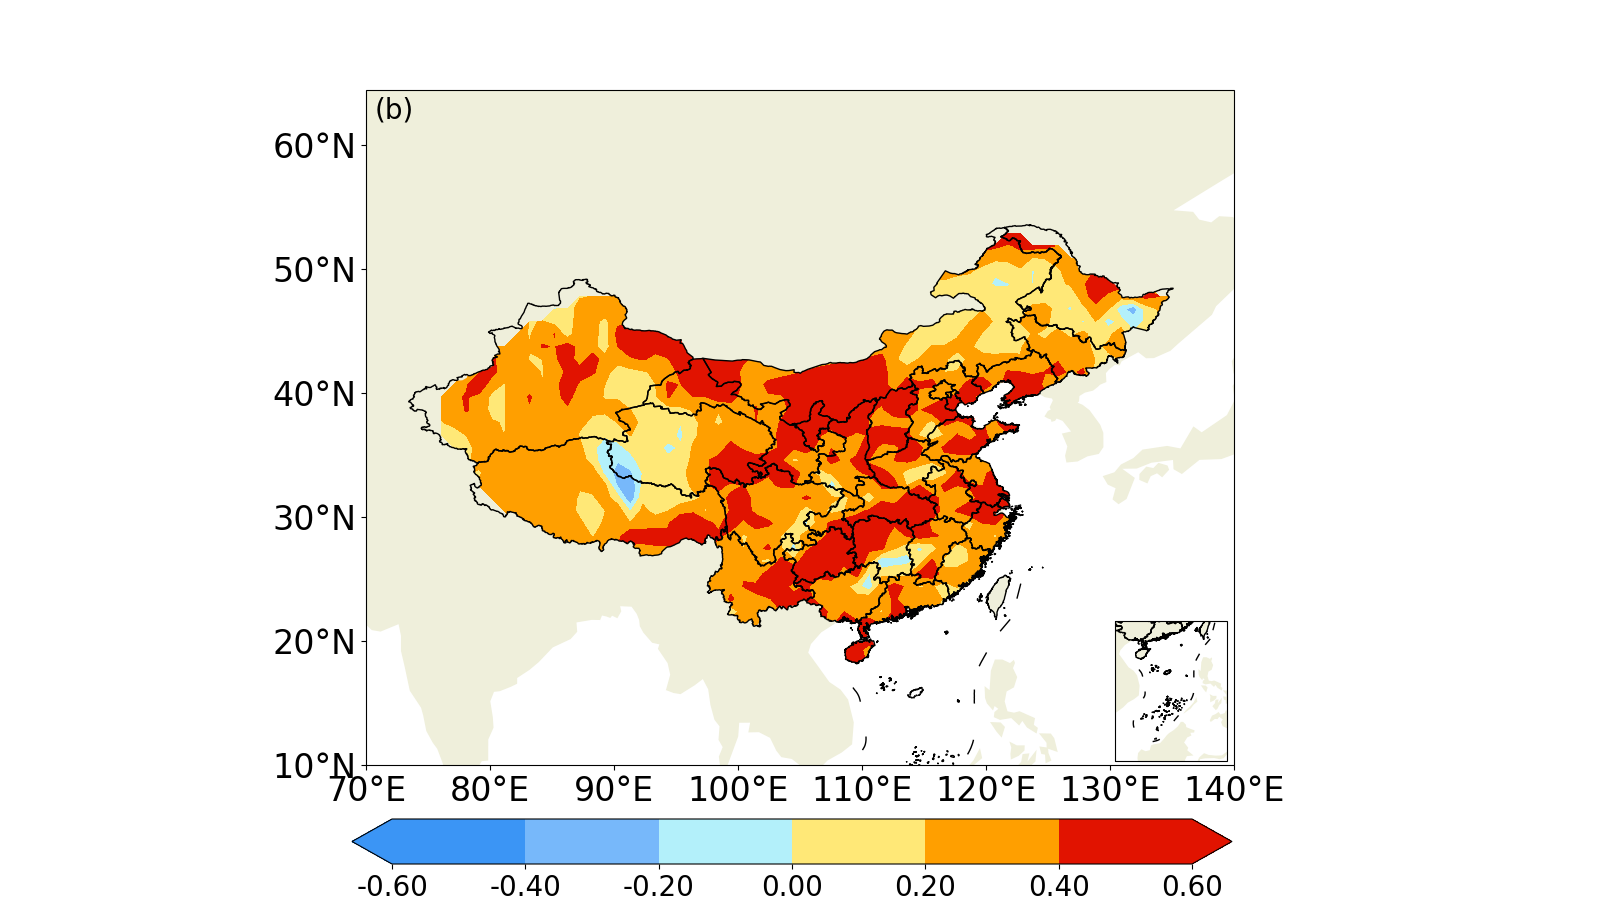

In [8]:
import os
import numpy as np
from netCDF4 import Dataset
import xlwt
import pandas as pd
import xarray as xr
from metpy.interpolate import inverse_distance_to_grid
from functools import reduce
import sys
import maskout
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib as mpl
import cartopy.feature as cfeature
from netCDF4 import Dataset
from cartopy.util import add_cyclic_point
import matplotlib.colors as colors
import matplotlib.ticker as ticker
from scipy.interpolate import griddata

np.set_printoptions(suppress=True)

# draw_what = prmse
df = pd.read_csv('E:\\D1\\f01\\xg6\\result.csv')
df = df.drop(['time', 'Precip'], axis=1)
df = df.drop_duplicates('Stn_No')
df_mode = tcc_sd

# 按照'Stn_No'列来合并数据表
df_final = pd.merge(df, df_mode, how='left', on='Stn_No')
df_final = df_final.dropna()
# df_final = df_final.drop(['mod_rmse','sd_rmse'], axis=1)

# 显示结果
min_long = df_final['Long'].min()/100
max_long = df_final['Long'].max()/100
min_lat = df_final['Lat'].min()/100
max_lat = df_final['Lat'].max()/100
target_lons = np.arange(70, 140, 1)
target_lats = np.arange(60, 0, -1)

# 创建目标经纬度的网格
target_grid_lon, target_grid_lat = np.meshgrid(target_lons, target_lats)

# 插值
grid_z = griddata((df_final['Long']/100, df_final['Lat']/100),df_final['tcc'], (target_grid_lon, target_grid_lat),method='linear')
# print(grid_z)
# 创建插值后的xarray.DataArray
draw_what = xr.DataArray(grid_z, coords=[('lat', target_lats), ('lon', target_lons)])

# 显示结果
print(draw_what)

class MidpointNormalize(colors.Normalize): 
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y))



lon = np.linspace(70, 140, np.shape(draw_what)[1])
lat = np.linspace(60, 0, np.shape(draw_what)[0])
# # 画下面的彩色条子
min_of_draw_what = -0.6
max_of_draw_what = 0.6
# min_of_draw_what = round(float(np.min(draw_what))*0.8, 2)
# max_of_draw_what = round(float(np.max(draw_what))*0.8, 2)
lim = np.concatenate((np.linspace(min_of_draw_what,0,4),np.delete(np.linspace(0,max_of_draw_what,4), 0)),axis=0)
# lim = [0,0.2,0.4,0.6]


# 地图界限
with open('../../CN-border-La.gmt') as src:
    context = src.read()
    blocks = [cnt for cnt in context.split('>') if len(cnt) > 0]
    borders = [np.fromstring(block, dtype=float, sep=' ') for block in blocks]

fig = plt.figure(figsize=(16,9),facecolor='white')
myproj = ccrs.PlateCarree(central_longitude=0.0)#ccrs跟绘地图有关#调整图像中心位置
ax = fig.add_axes([0.10, 0.15, 0.8, 0.75],projection=myproj)#add_axes通过相对位置增加子图 
ax.add_feature(cfeature.LAND.with_scale('110m'))
for line in borders:
    ax.plot(line[0::2], line[1::2], '-', lw=1, color='k',
            transform=ccrs.Geodetic())
    
# Plot gridlines绘制网格线
#ax.gridlines(linestyle='--')

# Set figure extent设置图范围
ax.set_extent([70, 140, 10, 60])#摆正图像
# ax.set_xticks([70,80,90,100,110,120,130,140],crs=ccrs.PlateCarree())
# ax.set_yticks([10,20,30,40,50],crs=ccrs.PlateCarree())
ax.set_xticks(range(70,141,10),crs=ccrs.PlateCarree())
ax.set_yticks(range(10,61,10),crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(zero_direction_label=False)
lat_formatter = LatitudeFormatter()#定义一种坐标刻度样式为维度刻度	
ax.xaxis.set_major_formatter(lon_formatter)#改变X轴主刻度为经度样式
ax.yaxis.set_major_formatter(lat_formatter)
plt.tick_params(axis='both',labelsize=24)#刻度的字号
cmap1 = mpl.colors.ListedColormap(['#3B95F5', '#4FA4F5', '#77B8FA', '#95D2FA', '#B3F0FA','#FFE877', '#FFBF3B', '#FF9F00', '#FF3100', '#E11300'])#暖大
# cmap1.set_over('darkred')
# cmap1.set_under('navy')    #22就是最后一年，2016年
cf=plt.contourf(lon,lat,draw_what,levels=lim,cmap =cmap1,extend='both',zorder=0,transform=ccrs.PlateCarree(),norm=MidpointNormalize(midpoint=0))#画出等高线


colors =mpl.colors.ListedColormap(['black'])
# plt.title('precipitation anomaly', fontsize=14)
#plt.legend((),('A1',),loc='upper left',fontsize=20,ncol=2)
# plt.title('D2',fontsize=60,loc='left',y=0.85,x=0.02)#标题和标题大小
formatter = ticker.FormatStrFormatter('%.2f')
cbar=plt.colorbar(cf,cax=fig.add_axes([0.22, 0.04, 0.55, 0.05]),format=formatter, orientation='horizontal',cmap=cmap1)
cbar.ax.tick_params(labelsize=20)#条子的字号

clip=maskout.shp2clip(cf,ax, r'../../data/province/china0.shp')
sub_ax = fig.add_axes([0.662, 0.155, 0.14, 0.155],projection=myproj)#小南海的位置
sub_ax.add_feature(cfeature.LAND.with_scale('110m'))
for line in borders:
    sub_ax.plot(line[0::2], line[1::2], '-', lw=1, color='k',
                transform=ccrs.Geodetic())
# Set figure extent设置图范围
sub_ax.set_extent([105, 125, 0, 25]) 
plt.subplots_adjust()
plt.text(.01, .99, '(b)', ha='left', va='top', transform=ax.transAxes, fontsize=20)
plt.show()
plt.savefig("../pictures/tcc/b.svg",format="svg")